In [1]:
# !git clone https://github.com/JJGO/UniverSeg
# !python -m pip install -r ./UniverSeg/requirements.txt

In [1]:
import math
import itertools
import os 
import sys
import random
import time
import pickle
from collections import defaultdict

from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt

import einops as E

import pandas as pd

In [2]:
from pathlib import Path
os.chdir("/nfs/norasys/notebooks/machauep/")

In [3]:
import sys
sys.path.append('UniverSeg')

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

from universeg import universeg
universeg = universeg(pretrained=True)
_ = universeg.to(device)

2026-03-12 12:48:05.192684: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 12:48:05.205735: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773316085.219771 1357081 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773316085.224095 1357081 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773316085.236261 1357081 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [4]:
# needed ?
from Data.DSHandler import DSHandler
DSHandler = DSHandler()

In [5]:
from Data.DataLoader_GPUnet import DataLoader_GPUnet
from Data.DataGenerator import DataGenerator
from Helpers import Helpers
Helpers = Helpers()

# Generate Data (will overwrite existing Data if executed!)

In [31]:
DataLoader = NoraDataLoaderV3(val_size=0.0, mode='testing_body')

going to load 2 items
XX


In [32]:
import pickle

# --- Code to generate and save the datasets ---
def gen_save_ds(path, num_ds=100, max_data_points=100, len_p_set=16, offset=5):
    for i in range(0, num_ds):

        ds, offsets = DataLoader.get_data_points_from_one_task(max_data_points=max_data_points+len_p_set, offset=offset)

        first_16 = ds.take(len_p_set)
        ds = ds.skip(len_p_set)

        with open(f'{path}/{str(i)}_offsets.pkl', "wb") as f:
            pickle.dump(offsets, f)

        DSHandler.save_tf_dataset_2D(ds, str(i)+"_2d_ds_body", path)
        DSHandler.save_tf_dataset_2D(first_16, str(i)+"_support_prompt_body", path)

In [33]:
gen_save_ds('Data/2D/gpu_net/Body/offset_10_2', num_ds=100, offset=10)

Creating new Data Points ...
Current task: 73
It took 11 seconds
Creating new Data Points ...
Current task: 41
It took 58 seconds
Creating new Data Points ...
Current task: 24
It took 31 seconds
Creating new Data Points ...
Current task: 15
It took 16 seconds
Creating new Data Points ...
Current task: 4
It took 11 seconds
Creating new Data Points ...
Current task: 1
It took 5 seconds
Creating new Data Points ...
Current task: 30
It took 24 seconds
Creating new Data Points ...
Current task: 63
It took 24 seconds
Creating new Data Points ...
Current task: 1
It took 9 seconds
Creating new Data Points ...
Current task: 42
It took 13 seconds
Creating new Data Points ...
Current task: 7
It took 6 seconds
Creating new Data Points ...
Current task: 70
It took 9 seconds
Creating new Data Points ...
Current task: 80
It took 36 seconds
Creating new Data Points ...
Current task: 1
It took 6 seconds
Creating new Data Points ...
Current task: 3
It took 7 seconds
Creating new Data Points ...
Current 

# Helpers

In [6]:
def visualize_tensors(tensors, col_wrap=8, col_names=None, title=None):
    M = len(tensors)
    N = len(next(iter(tensors.values())))

    cols = col_wrap
    rows = math.ceil(N/cols) * M

    d = 2.5
    fig, axes = plt.subplots(rows, cols, figsize=(d*cols, d*rows))
    if rows == 1:
      axes = axes.reshape(1, cols)

    for g, (grp, tensors) in enumerate(tensors.items()):
        for k, tensor in enumerate(tensors):
            col = k % cols
            row = g + M*(k//cols)
            x = tensor.detach().cpu().numpy().squeeze()
            ax = axes[row,col]
            if len(x.shape) == 2:
                ax.imshow(x,vmin=0, vmax=1, cmap='gray')
            else:
                ax.imshow(E.rearrange(x,'C H W -> H W C'))
            if col == 0:
                ax.set_ylabel(grp, fontsize=16)
            if col_names is not None and row == 0:
                ax.set_title(col_names[col])

    for i in range(rows):
        for j in range(cols):
            ax = axes[i,j]
            ax.grid(False)
            ax.set_xticks([])
            ax.set_yticks([])

    if title:
        plt.suptitle(title, fontsize=20)

    plt.tight_layout()

In [55]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_dataset(dataset, max_samples=5, title=None, contrast=1):
    """
    Visualize (x, y, p) tensors from a TF dataset as columns: 
    row 0 = x + y, row 1 = p (all grayscale).

    Args:
        dataset: Iterable of (x, y, p) tensors (TF tensors or NumPy arrays).
        max_samples (int): Maximum number of samples (columns) to plot.
        title (str): Optional figure title.
        contrast (float): Contrast multiplier for y and p.
    """
    # Collect samples
    samples = []
    for i, (x, y, p) in enumerate(dataset):
        samples.append((x, y, p))
        if max_samples is not None and i + 1 >= max_samples:
            break

    N = len(samples)
    rows, cols = 2, N  # 2 rows (x+y, p), columns = number of samples

    d = 2.5
    fig, axes = plt.subplots(rows, cols, figsize=(d*cols, d*rows))

    # Ensure axes is always 2D
    if N == 1:
        axes = axes.reshape(2, 1)

    for k, (x, y, p) in enumerate(samples):
        # Convert to numpy
        x_np = x.numpy().squeeze() if hasattr(x, "numpy") else x.squeeze()
        y_np = y.numpy().squeeze() if hasattr(y, "numpy") else y.squeeze()
        p_np = p.numpy().squeeze() if hasattr(p, "numpy") else p.squeeze()

        # Apply contrast for y and p
        y_np[y_np > 0] = contrast
        if p_np.ndim == 3:
            p1 = p_np[...,1]
            p1[p1 > 0] = contrast
        else:
            p1 = p_np

        # Plot x + y
        ax = axes[0, k]
        ax.imshow(x_np + y_np*2, cmap='gray')
        ax.set_xticks([]); ax.set_yticks([])
        if k == 0:
            ax.set_ylabel("Query + Target", fontsize=14)

        # Plot p
        ax = axes[1, k]
        if p_np.ndim == 3:
            ax.imshow(p_np[...,0] + p1*2, cmap='gray')
        else:
            ax.imshow(p_np, cmap='gray')
        ax.set_xticks([]); ax.set_yticks([])
        if k == 0:
            ax.set_ylabel("Prompt", fontsize=14)

    if title:
        plt.suptitle(title, fontsize=20)

    plt.tight_layout()
    plt.show()

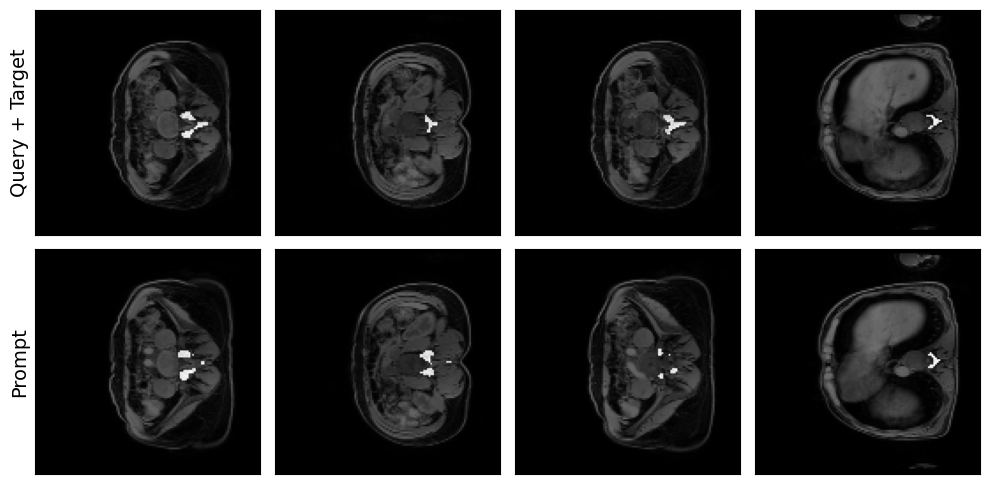

In [56]:
i = 0
ds = DSHandler.load_tf_dataset_2D(f'{i}_2d_ds_body', f'Data/2D/gpu_net/Body/offset_10_2')

visualize_dataset(ds, max_samples=4)

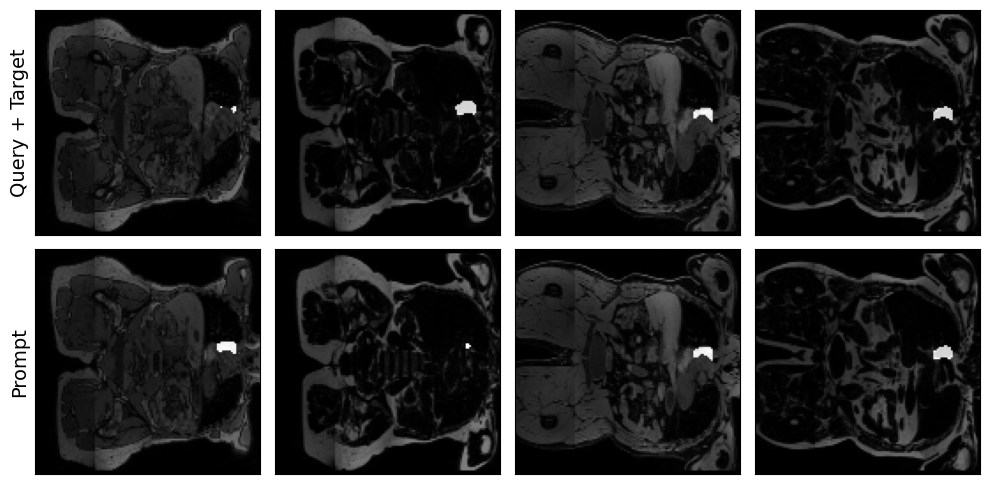

In [57]:
i = 1
ds = DSHandler.load_tf_dataset_2D(f'{i}_2d_ds_body', f'Data/2D/gpu_net/Body/offset_10_2')

visualize_dataset(ds, max_samples=4)

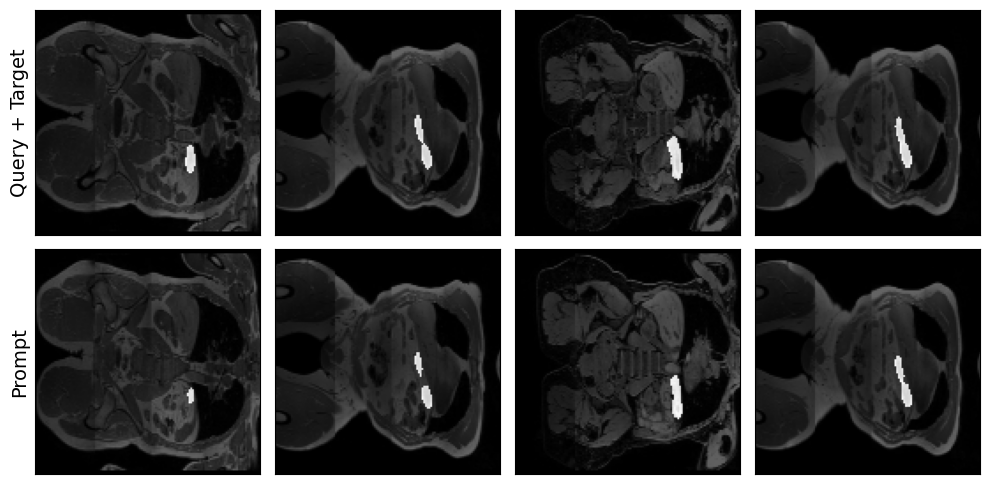

In [58]:
i = 3
ds = DSHandler.load_tf_dataset_2D(f'{i}_2d_ds_body', f'Data/2D/gpu_net/Body/offset_10_2')

visualize_dataset(ds, max_samples=4)

In [7]:
def calc_avg_dices(path, model):
    # path = "Data/2D/gpu_net/Body/offset_5"
    # model = 'V1_9_3'
    total_prompt = 0.0
    total_univer = 0.0

    for i in range(num_ds): 
        with open(f'{path}/{str(i)}_dice_{model}.pkl', "rb") as f:
            # d = prompt unet | universeg
            d = pickle.load(f)
            total_prompt += d[0]
            total_univer += d[1]

    total_prompt/=num_ds
    total_univer/=num_ds

    print(f'Prompt U-Net Dice: {total_prompt}')
    print(f'UniverSeg Dice: {total_univer}')
    return total_prompt, total_univer

In [8]:
# --- Code to load a prompt set ---
def load_prompt_support_set(num, path):
    ds_prompt = DSHandler.load_tf_dataset_2D(str(num)+"_support_prompt_body", path)

    prompt_list = []
    for e,(x,y,p) in enumerate(ds_prompt):
        if e==16:
            break
        prompt_list.append(p)

    support_prompt = tf.stack(prompt_list, axis=0)


    # Load set of prompts for UniverSeg only once
    support_images = support_prompt[...,0] 
    support_labels = support_prompt[...,1]

    support_images = tf.expand_dims(support_images, axis=1)
    support_labels = tf.expand_dims(support_labels, axis=1)
    # print(support_images.shape)
    # 16,1,128,128

    support_images = support_images.numpy()
    support_labels = support_labels.numpy()

    # print(f'p (img): {np.min(support_images)} - {np.max(support_images)} |  p (label): {np.min(support_labels)} - {np.max(support_labels)}')

    support_images = torch.from_numpy(support_images).to(device)
    support_labels = torch.from_numpy(support_labels).to(device)
    
    return support_images, support_labels

Example:

In [10]:
support_images, support_labels = load_prompt_support_set(1, path="Data/2D/gpu_net/Body/offset_5")

I0000 00:00:1773316231.591240 1357081 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46563 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:2a:00.0, compute capability: 8.9
2026-03-12 12:50:31.774642: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-03-12 12:50:31.850104: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
support_images = support_images.cpu()
support_labels = support_labels.cpu()

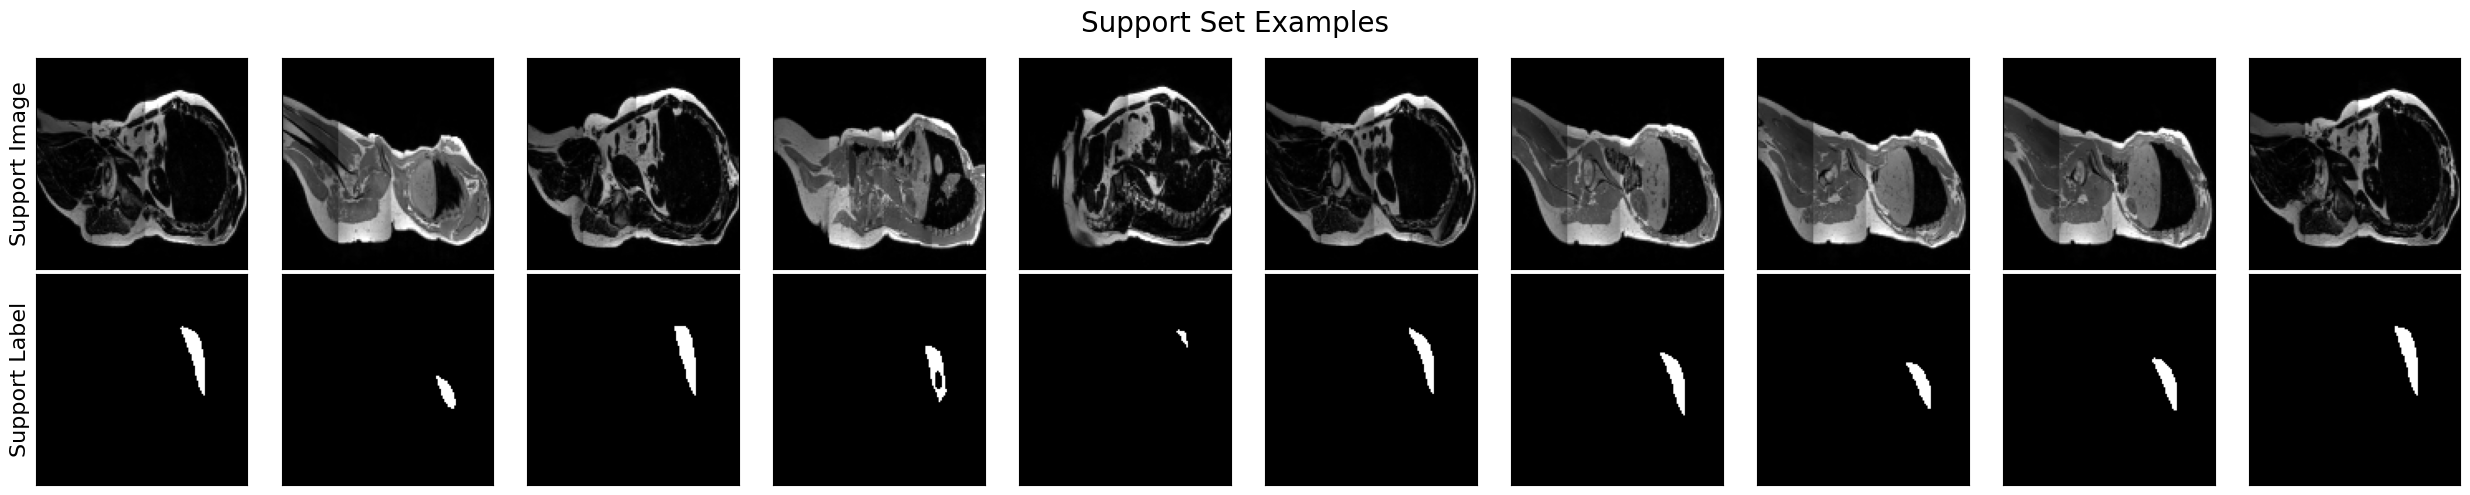

In [12]:
n_viz = 10
visualize_tensors({
    'Support Image': support_images[:n_viz],
    'Support Label': support_labels[:n_viz],
}, col_wrap=10, title='Support Set Examples')

# V2_1 +/- 5

In [14]:
avg_universeg = 0.0
avg_promptunet = 0.0

model = 'V2_1'
path = "Data/2D/gpu_net/Body/offset_5"
p_unet = tf.keras.models.load_model(f'prompt_unet/prompt_unet{model}.keras')
num_ds = 100
threshold = 0.45

for i in range(num_ds):
    dice_per_task_prompt = 0.0
    dice_per_task_univers = 0.0
    
    test_ds = DSHandler.load_tf_dataset_2D(str(i)+"_2d_ds_body", path)
    support_images, support_labels = load_prompt_support_set(i, path)
    
    with open(f'{path}/{str(i)}_offsets.pkl', "rb") as f:
            offsets = pickle.load(f)
    
    for e, (image, label, prompt) in enumerate(test_ds):    

        # --- Prompt U-Net ---
        image = Helpers.shaping(image)
        prompt = Helpers.shaping(prompt)
        
        # print(image.shape, prompt.shape)
        
        # Helpers.plot_one_dp(image, label, prompt, offset=offsets[e])
        
        pred = p_unet.predict([image, prompt], verbose=0)
        pred = tf.where(pred < threshold, 0.0, pred)
        pred = tf.where(pred >= threshold, 1.0, pred)
        
        
        dice_punet = Helpers.dice_score_tf(tf.squeeze(label), tf.squeeze(pred))
        dice_punet = dice_punet.numpy()
        dice_per_task_prompt += dice_punet
        
        # print("P Unet:", dice_punet)
        # Helpers.plot_result(image, label, prompt, pred, offsets[e], "")

        # --- UniverSeg ---
        image = tf.squeeze(image, axis=-1)
        label = tf.squeeze(label, axis=-1)
        label = tf.expand_dims(label, axis=0)
        # image and label: 1,128,128

        image = image.numpy()
        label = label.numpy()

        # print(f'x: {np.min(image)} - {np.max(image)} | y: {np.min(label)} - {np.max(label)}')

        image = torch.from_numpy(image).to(device)
        label = torch.from_numpy(label).to(device)

        # print(support_images[None].shape)

        # insert query image and support prompt set
        logits = universeg(image[None], support_images[None], support_labels[None])[0]
        pred = torch.sigmoid(logits)
        pred = (pred > threshold).int()  # Test!!!
        
        label = label.cpu().detach().numpy()
        pred = pred.cpu().detach().numpy()
        
        dice_univer = Helpers.dice_numpy(np.squeeze(label), np.squeeze(pred))
        dice_per_task_univers += dice_univer
        # print("UniverSeg:", dice_univer)
        
        # combined = pred[0, ...] + image[0, ...].cpu().detach().numpy()
        # plt.imshow(combined)
        # plt.show()
        # print("--------------------------------------------------------------------------------------------------------------------------------")
    
    # len(test_ds) = 100
    dice_per_task_prompt /= 100 
    dice_per_task_univers /= 100
    
    avg_promptunet += dice_per_task_prompt
    avg_universeg += dice_per_task_univers
    
    with open(f'{path}/{str(i)}_dice_{model}.pkl', "wb") as f:
        pickle.dump((dice_per_task_prompt,dice_per_task_univers), f)

avg_promptunet /= num_ds
avg_universeg /= num_ds

print(f'Prompt U-Net: {avg_promptunet:.3f}')
print(f'UniverSeg: {avg_universeg:.3f}')

2026-03-03 11:43:14.834612: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
I0000 00:00:1772534596.054606     114 service.cc:152] XLA service 0x7f78f80038e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772534596.054635     114 service.cc:160]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-03-03 11:43:16.109750: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1772534596.434178     114 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772534599.184167     114 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-03-03 11:43:47.106822: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_R

Prompt U-Net: 0.875
UniverSeg: 0.785


Old Model:

In [15]:
_,_ = calc_avg_dices(path="Data/2D/gpu_net/Body/offset_5", model = 'V1_9_3')

Prompt U-Net Dice: 0.8398056626319885
UniverSeg Dice: 0.7848455309867859


New Model:

In [18]:
_,_ = calc_avg_dices(path="Data/2D/gpu_net/Body/offset_5", model = 'V2_1')

Prompt U-Net Dice: 0.8745386600494385
UniverSeg Dice: 0.7848455309867859


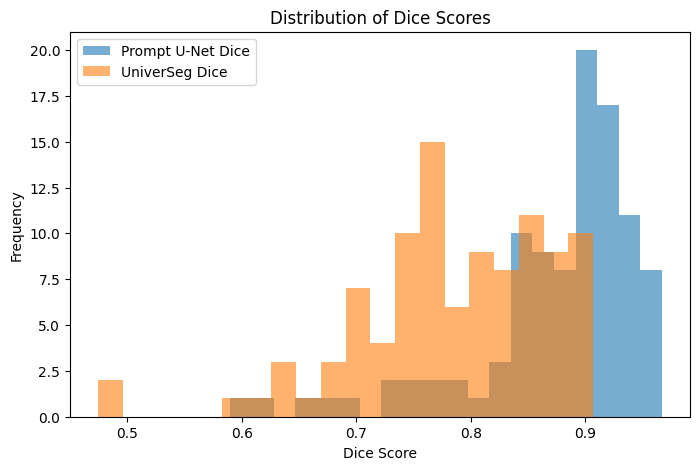

/tmp/ipykernel_67/469861022.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


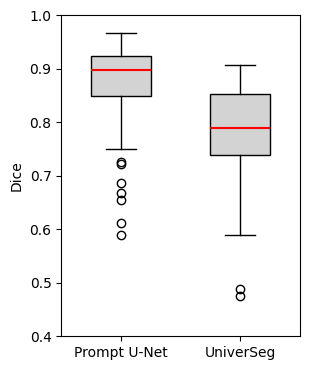

In [10]:
# --- Distribution ---

import pickle

path = "Data/2D/gpu_net/Body/offset_5"
model = 'V2_1'
prompt_dices = []
univer_dices = []

for i in range(num_ds): 
    with open(f'{path}/{str(i)}_dice_{model}.pkl', "rb") as f:
        d = pickle.load(f)
        prompt_dices.append(d[0])
        univer_dices.append(d[1])

# Plot distribution
plt.figure(figsize=(8, 5))
plt.hist(prompt_dices, bins=20, alpha=0.6, label='Prompt U-Net Dice')
plt.hist(univer_dices, bins=20, alpha=0.6, label='UniverSeg Dice')
plt.xlabel("Dice Score")
plt.ylabel("Frequency")
plt.title("Distribution of Dice Scores")
plt.legend()
plt.show()

# Compact boxplot comparison (y-axis to 1.0)
plt.figure(figsize=(3.2, 3.8))
plt.boxplot(
    [prompt_dices, univer_dices],
    labels=['Prompt U-Net', 'UniverSeg'],
    widths=0.5,
    patch_artist=True,
    boxprops=dict(facecolor='lightgray', color='black'),
    medianprops=dict(color='red', linewidth=1.5),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
)
# plt.ylabel("Dice Score")
plt.ylabel("Dice")
plt.ylim(0.5, 1.0)
plt.yticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])  # evenly spaced ticks
plt.tight_layout()
plt.show()

# V2_1 +/- 10

In [19]:
avg_universeg = 0.0
avg_promptunet = 0.0

model = 'V2_1'
path = "Data/2D/gpu_net/Body/offset_10_2"
p_unet = tf.keras.models.load_model(f'prompt_unet/prompt_unet{model}.keras')
num_ds = 100
threshold = 0.45

for i in range(num_ds):
    dice_per_task_prompt = 0.0
    dice_per_task_univers = 0.0
    
    test_ds = DSHandler.load_tf_dataset_2D(str(i)+"_2d_ds_body", path)
    support_images, support_labels = load_prompt_support_set(i, path)
    
    with open(f'{path}/{str(i)}_offsets.pkl', "rb") as f:
            offsets = pickle.load(f)
    
    for e, (image, label, prompt) in enumerate(test_ds):    

        # --- Prompt U-Net ---
        image = Helpers.shaping(image)
        prompt = Helpers.shaping(prompt)
        
        # print(image.shape, prompt.shape)
        
        # Helpers.plot_one_dp(image, label, prompt, offset=offsets[e])
        
        pred = p_unet.predict([image, prompt], verbose=0)
        pred = tf.where(pred < threshold, 0.0, pred)
        pred = tf.where(pred >= threshold, 1.0, pred)
        
        
        dice_punet = Helpers.dice_score_tf(tf.squeeze(label), tf.squeeze(pred))
        dice_punet = dice_punet.numpy()
        dice_per_task_prompt += dice_punet
        
        # print("P Unet:", dice_punet)
        # Helpers.plot_result(image, label, prompt, pred, offsets[e], "")

        # --- UniverSeg ---
        image = tf.squeeze(image, axis=-1)
        label = tf.squeeze(label, axis=-1)
        label = tf.expand_dims(label, axis=0)
        # image and label: 1,128,128

        image = image.numpy()
        label = label.numpy()

        # print(f'x: {np.min(image)} - {np.max(image)} | y: {np.min(label)} - {np.max(label)}')

        image = torch.from_numpy(image).to(device)
        label = torch.from_numpy(label).to(device)

        # print(support_images[None].shape)

        # insert query image and support prompt set
        logits = universeg(image[None], support_images[None], support_labels[None])[0]
        pred = torch.sigmoid(logits)
        pred = (pred > threshold).int()  # Test!!!
        
        label = label.cpu().detach().numpy()
        pred = pred.cpu().detach().numpy()
        
        dice_univer = Helpers.dice_numpy(np.squeeze(label), np.squeeze(pred))
        dice_per_task_univers += dice_univer
        # print("UniverSeg:", dice_univer)
        
        # combined = pred[0, ...] + image[0, ...].cpu().detach().numpy()
        # plt.imshow(combined)
        # plt.show()
        # print("--------------------------------------------------------------------------------------------------------------------------------")
    
    # len(test_ds) = 100
    dice_per_task_prompt /= 100 
    dice_per_task_univers /= 100
    
    avg_promptunet += dice_per_task_prompt
    avg_universeg += dice_per_task_univers
    
    with open(f'{path}/{str(i)}_dice_{model}.pkl', "wb") as f:
        pickle.dump((dice_per_task_prompt,dice_per_task_univers), f)

avg_promptunet /= num_ds
avg_universeg /= num_ds

print(f'Prompt U-Net: {avg_promptunet:.3f}')
print(f'UniverSeg: {avg_universeg:.3f}')

2026-03-03 12:23:34.113972: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Prompt U-Net: 0.820
UniverSeg: 0.787


In [20]:
_,_ = calc_avg_dices(path="Data/2D/gpu_net/Body/offset_10_2", model = 'V2_1')

Prompt U-Net Dice: 0.820190966129303
UniverSeg Dice: 0.786577582359314


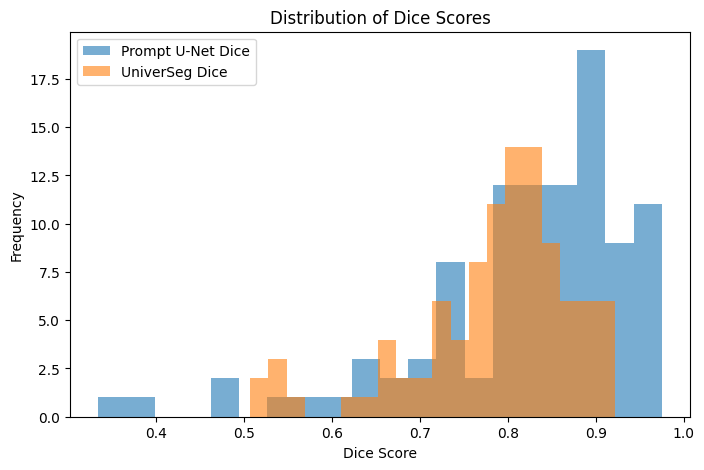

/tmp/ipykernel_67/972435557.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


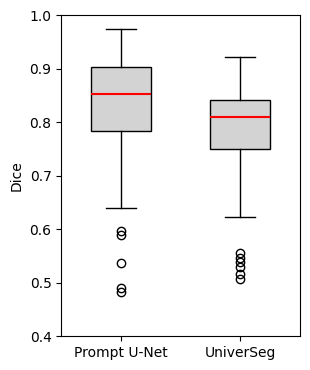

In [9]:
# --- Distribution ---

import pickle
num_ds = 100

path = "Data/2D/gpu_net/Body/offset_10_2"
model = 'V2_1'
prompt_dices = []
univer_dices = []

for i in range(num_ds): 
    with open(f'{path}/{str(i)}_dice_{model}.pkl', "rb") as f:
        d = pickle.load(f)
        prompt_dices.append(d[0])
        univer_dices.append(d[1])

# Plot distribution
plt.figure(figsize=(8, 5))
plt.hist(prompt_dices, bins=20, alpha=0.6, label='Prompt U-Net Dice')
plt.hist(univer_dices, bins=20, alpha=0.6, label='UniverSeg Dice')
plt.xlabel("Dice Score")
plt.ylabel("Frequency")
plt.title("Distribution of Dice Scores")
plt.legend()
plt.show()

# Compact boxplot comparison (y-axis to 1.0)
plt.figure(figsize=(3.2, 3.8))
plt.boxplot(
    [prompt_dices, univer_dices],
    labels=['Prompt U-Net', 'UniverSeg'],
    widths=0.5,
    patch_artist=True,
    boxprops=dict(facecolor='lightgray', color='black'),
    medianprops=dict(color='red', linewidth=1.5),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
)
# plt.ylabel("Dice Score")
plt.ylabel("Dice")
plt.ylim(0.5, 1.0)
plt.yticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])  # evenly spaced ticks
plt.tight_layout()
plt.show()